<a href="https://colab.research.google.com/github/EugOT/CN-pr-Allen-Brain/blob/main/redl_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

installing dependencies

In [6]:
# @title Install packages
!pip install pip --upgrade --quiet
!pip install brain_observatory_utilities --upgrade --quiet
!pip install pandas --quiet
!pip install seaborn --quiet

Import packages

In [7]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.manifold import TSNE

import brain_observatory_utilities.datasets.optical_physiology.data_formatting as ophys_formatting
import brain_observatory_utilities.utilities.general_utilities as utilities

from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

pd.set_option('display.max_columns', 500)

Load Dataset

In [8]:
# read data from cache
# or download if necessary

data_storage_directory = "./tmp"  # Note: this path must exist on your local drive
cache = VisualBehaviorOphysProjectCache.from_s3_cache(cache_dir=data_storage_directory)

session_table = cache.get_ophys_session_table()
experiment_table = cache.get_ophys_experiment_table()

/usr/local/lib/python3.10/dist-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_block_name`.

The data that was available in previous releases are stored in the block name containing 'change_detection' and can be accessed in the pandas table by using: 
	`stimulus_presentations[stimulus_presentations.stimulus_block_name.str.contains('change_detection')]`
  warnings.warn(


In [9]:
print (cache)
np.unique(session_table['image_set'])
session_table[session_table['image_set'] == 'images_G']


,behavior_session_id,ophys_container_id,mouse_id,indicator,full_genotype,driver_line,cre_line,reporter_line,sex,age_in_days,imaging_plane_group_count,project_code,session_type,session_number,image_set,behavior_type,experience_level,prior_exposures_to_session_type,prior_exposures_to_image_set,prior_exposures_to_omissions,date_of_acquisition,equipment_name,num_depths_per_area,ophys_experiment_id,num_targeted_structures
ophys_session_id,,,,,,,,,,,,,,,,,,,,,,,,,
1008003852,1008034648,"[1018027796, 1018027802, 1018027806, 101802780...",499478,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Vip-IRES-Cre],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,134,4,VisualBehaviorMultiscope4areasx2d,OPHYS_1_images_G,1,images_G,active_behavior,Familiar,0,10,0,2020-02-18 09:15:35.826000+00:00,MESO.1,2,"[1008408502, 1008408506, 1008408508, 100840850...",4
1009188505,1009248812,"[1018027796, 1018027799, 1018027802, 101802780...",499478,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Vip-IRES-Cre],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,137,4,VisualBehaviorMultiscope4areasx2d,OPHYS_3_images_G,3,images_G,active_behavior,Familiar,1,12,2,2020-02-21 09:10:02.977000+00:00,MESO.1,2,"[1009495873, 1009495875, 1009495876, 100949587...",4
1009837124,1009868108,"[1018027796, 1018027799, 1018027802, 101802780...",499478,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Vip-IRES-Cre],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,140,4,VisualBehaviorMultiscope4areasx2d,OPHYS_2_images_G_passive,2,images_G,passive_viewing,Familiar,0,13,3,2020-02-24 09:18:23.425000+00:00,MESO.1,2,"[1010092798, 1010092800, 1010092802, 101009280...",4
1011840561,1011885656,"[1018027796, 1018027799, 1018027802, 101802780...",499478,GCaMP6f,Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Vip-IRES-Cre],Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,148,4,VisualBehaviorMultiscope4areasx2d,OPHYS_3_images_G,3,images_G,active_behavior,Familiar,2,14,8,2020-03-03 09:25:13.752000+00:00,MESO.1,2,"[1012165644, 1012165646, 1012165647, 101216565...",4
975050422,975239345,"[1018027747, 1018027750, 1018027753, 101802775...",484408,GCaMP6f,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-G...,"[Slc17a7-IRES2-Cre, Camk2a-tTA]",Slc17a7-IRES2-Cre,Ai93(TITL-GCaMP6f),M,116,4,VisualBehaviorMultiscope4areasx2d,OPHYS_1_images_G,1,images_G,active_behavior,Familiar,0,9,1,2019-11-01 09:25:23.468000+00:00,MESO.1,2,"[975608406, 975608408, 975608410, 975608412, 9...",4
975929719,976039179,"[1018027747, 1018027750, 1018027753, 101802775...",484408,GCaMP6f,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-G...,"[Slc17a7-IRES2-Cre, Camk2a-tTA]",Slc17a7-IRES2-Cre,Ai93(TITL-GCaMP6f),M,119,4,VisualBehaviorMultiscope4areasx2d,OPHYS_2_images_G_passive,2,images_G,passive_viewing,Familiar,0,10,2,2019-11-04 09:21:00.916000+00:00,MESO.1,2,"[976300311, 976300313, 976300315, 976300317, 9...",4
976865980,976964099,"[1018027747, 1018027750, 1018027753, 101802775...",484408,GCaMP6f,Slc17a7-IRES2-Cre/wt;Camk2a-tTA/wt;Ai93(TITL-G...,"[Slc17a7-IRES2-Cre, Camk2a-tTA]",Slc17a7-IRES2-Cre,Ai93(TITL-GCaMP6f),M,120,4,VisualBehaviorMultiscope4areasx2d,OPHYS_3_images_G,3,images_G,active_behavior,Familiar,0,11,3,2019-11-05 13:35:33.124000+00:00,MESO.1,2,"[977220481, 977220483, 977220485, 977220487, 9...",4
993228542,993241575,"[1018028254, 1018028261, 1018028267, 101802827...",485689,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),M,148,4,VisualBehaviorMultiscope4areasx2d,OPHYS_1_images_G,1,images_G,active_behavior,Familiar,0,16,0,2019-12-09 08:55:07.533000+00:00,MESO.1,2,"[993369355, 993369356, 993369357, 993369358, 9...",4
993504279,993532086,"[1018028254, 1018028273, 1018058743, 101805874...",485689,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),M,149,3,VisualBehaviorMultiscope4areasx2d,OPHYS_2_images_G_passive,2,images_G,passive_viewing,Familiar,0,17,1,2019-12-10 12:04:51.604000+00:00,MESO.1,2,"[993619354, 993619355, 99

In [10]:
experiment_table.head()

,behavior_session_id,ophys_session_id,ophys_container_id,mouse_id,indicator,full_genotype,driver_line,cre_line,reporter_line,sex,age_in_days,imaging_depth,targeted_structure,targeted_imaging_depth,imaging_plane_group,project_code,session_type,session_number,image_set,behavior_type,passive,experience_level,prior_exposures_to_session_type,prior_exposures_to_image_set,prior_exposures_to_omissions,date_of_acquisition,equipment_name,published_at,isi_experiment_id,file_id
ophys_experiment_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
951980471,951520319,951410079,1018028342,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,150,VISp,150,0,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,0
951980473,951520319,951410079,1018028345,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,225,VISp,225,0,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,1
951980475,951520319,951410079,1018028339,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,75,VISp,75,1,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,2
951980479,951520319,951410079,1018028354,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,150,VISl,150,2,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,3
951980481,951520319,951410079,1018028357,457841,GCaMP6f,Sst-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt,[Sst-IRES-Cre],Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),F,206,225,VISl,225,2,VisualBehaviorMultiscope,OPHYS_1_images_A,1,A,active_behavior,False,Familiar,0,65,0,2019-09-20 09:59:38.837000+00:00,MESO.1,2021-03-25,848974280,4


In [75]:
ophys_session_id = 1009315444
session_table.loc[ophys_session_id]

behavior_session_id                                                       1009374318
ophys_container_id                 [1018027962, 1018027965, 1018027968, 101802797...
mouse_id                                                                      489065
indicator                                                                    GCaMP6f
full_genotype                          Vip-IRES-Cre/wt;Ai148(TIT2L-GC6f-ICL-tTA2)/wt
driver_line                                                           [Vip-IRES-Cre]
cre_line                                                                Vip-IRES-Cre
reporter_line                                             Ai148(TIT2L-GC6f-ICL-tTA2)
sex                                                                                F
age_in_days                                                                      201
imaging_plane_group_count                                                          4
project_code                                       VisualBehavior

In [76]:
experiments = {}
ophys_experiment_ids = session_table.loc[ophys_session_id]['ophys_experiment_id']
for ophys_experiment_id in ophys_experiment_ids:
    experiments[ophys_experiment_id] = cache.get_behavior_ophys_experiment(ophys_experiment_id)

behavior_ophys_experiment_1009495886.nwb: 100%|██████████| 270M/270M [00:12<00:00, 21.4MMB/s]
behavior_ophys_experiment_1009495888.nwb: 100%|██████████| 239M/239M [00:11<00:00, 20.2MMB/s]
behavior_ophys_experiment_1009495889.nwb: 100%|██████████| 257M/257M [00:12<00:00, 20.4MMB/s]
behavior_ophys_experiment_1009495892.nwb: 100%|██████████| 233M/233M [00:11<00:00, 20.6MMB/s]
behavior_ophys_experiment_1009495893.nwb: 100%|██████████| 257M/257M [00:12<00:00, 20.3MMB/s]
behavior_ophys_experiment_1009495897.nwb: 100%|██████████| 262M/262M [00:13<00:00, 19.6MMB/s]


In [77]:
experiment = experiments[ophys_experiment_ids[0]]
experiment.cell_specimen_table.head()

,cell_roi_id,height,mask_image_plane,max_correction_down,max_correction_left,max_correction_right,max_correction_up,valid_roi,width,x,y,roi_mask
cell_specimen_id,,,,,,,,,,,,
1120055760,1115390260,15,0,8.0,9.0,6.0,4.0,True,15,77,453,"[[False, False, False, False, False, False, Fa..."
1120055501,1115390266,14,0,8.0,9.0,6.0,4.0,True,16,117,352,"[[False, False, False, False, False, False, Fa..."
1120055273,1115390268,16,0,8.0,9.0,6.0,4.0,True,17,200,374,"[[False, False, False, False, False, False, Fa..."
1120055050,1115390271,14,0,8.0,9.0,6.0,4.0,True,15,282,336,"[[False, False, False, False, False, False, Fa..."
1120055375,1115390272,14,0,8.0,9.0,6.0,4.0,True,21,191,346,"[[False, False, False, False, False, False, Fa..."


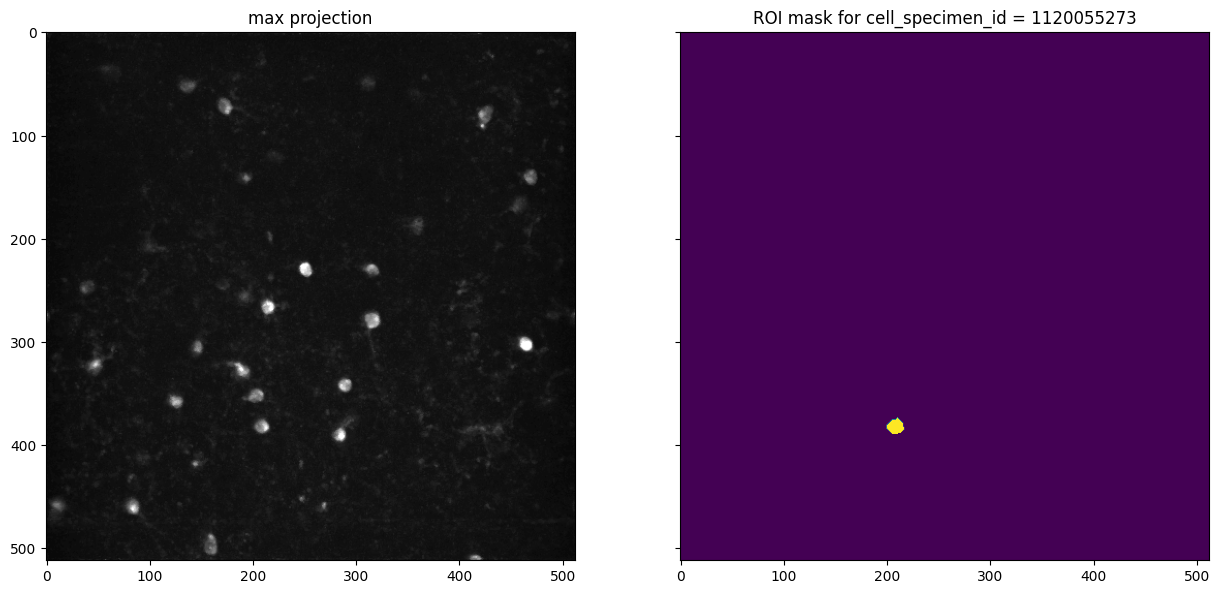

In [78]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8), sharex=True, sharey=True)
ax[0].imshow(experiment.max_projection, cmap='gray')
ax[0].set_title('max projection')

cell_specimen_id = experiment.cell_specimen_table.index[2]
ax[1].imshow(experiment.cell_specimen_table.loc[cell_specimen_id]['roi_mask'])
ax[1].set_title('ROI mask for cell_specimen_id = {}'.format(cell_specimen_id))
fig.show()

In [79]:
neural_data = []
for ophys_experiment_id in tqdm(experiments.keys()): #tqdm is a package that shows progress bars for items that are iterated over
    this_experiment = experiments[ophys_experiment_id]
    this_experiment_neural_data = ophys_formatting.build_tidy_cell_df(this_experiment)

    # add some columns with metadata for the experiment
    metadata_keys = [
      'ophys_experiment_id',
      'ophys_session_id',
      'targeted_structure',
      'imaging_depth',
      'equipment_name',
      'cre_line',
      'mouse_id',
      'sex',
    ]
    for metadata_key in metadata_keys:
        this_experiment_neural_data[metadata_key] = this_experiment.metadata[metadata_key]

    # append the data for this experiment to a list
    neural_data.append(this_experiment_neural_data)

# concatate the list of dataframes into a single dataframe
neural_data = pd.concat(neural_data)

100%|██████████| 6/6 [00:02<00:00,  2.34it/s]


In [80]:
neural_data.head()

,timestamps,dff,events,filtered_events,cell_roi_id,cell_specimen_id,ophys_experiment_id,ophys_session_id,targeted_structure,imaging_depth,equipment_name,cre_line,mouse_id,sex
0,8.55969,0.370454,0.000000,0.000000,1115390260,1120055760,1009495886,1009315444,VISp,175,MESO.1,Vip-IRES-Cre,489065,F
1,8.65321,0.395247,0.000000,0.000000,1115390260,1120055760,1009495886,1009315444,VISp,175,MESO.1,Vip-IRES-Cre,489065,F
2,8.74673,1.258079,0.923164,0.664369,1115390260,1120055760,1009495886,1009315444,VISp,175,MESO.1,Vip-IRES-Cre,489065,F
3,8.84025,1.006836,0.000000,0.246182,1115390260,1120055760,1009495886,1009315444,VISp,175,MESO.1,Vip-IRES-Cre,489065,F
4,8.93377,1.109398,0.000000,0.012525,1115390260,1120055760,1009495886,1009315444,VISp,175,MESO.1,Vip-IRES-Cre,489065,F


In [81]:
cell_ids = neural_data['cell_specimen_id'].unique()
print('there are {} unique cells'.format(len(cell_ids)))
print('cell ids are: {}'.format(cell_ids))

there are 89 unique cells
cell ids are: [1120055760 1120055501 1120055273 1120055050 1120055375 1120054836
 1120056509 1120055116 1120056598 1120055950 1120056035 1120056089
 1120056192 1120056259 1120054947 1120055188 1120056820 1120056889
 1120056672 1120056451 1120056976 1120057075 1120056736 1120056355
 1120050733 1120050645 1120050670 1120050677 1120050634 1120050700
 1120050706 1120060900 1120060759 1120060695 1120060506 1120060660
 1120061562 1120060981 1120061084 1120061160 1120061676 1120061782
 1120061442 1120062382 1120061946 1120062067 1120061341 1120061210
 1120055407 1120055046 1120055206 1120055302 1120058049 1120057362
 1120058134 1120058557 1120057412 1120058644 1120057709 1120057627
 1120057867 1120058731 1120058992 1120056701 1120057181 1120056811
 1120056940 1120057963 1120057095 1120058670 1120059771 1120058629
 1120058494 1120058750 1120059322 1120058845 1120058797 1120058893
 1120058980 1120059034 1120060118 1120058567 1120059222 1120059610
 1120059384 1120059917

In [82]:
single_cell_timeseries = neural_data.query('cell_specimen_id == 1086613265')
single_cell_timeseries.head()

,timestamps,dff,events,filtered_events,cell_roi_id,cell_specimen_id,ophys_experiment_id,ophys_session_id,targeted_structure,imaging_depth,equipment_name,cre_line,mouse_id,sex


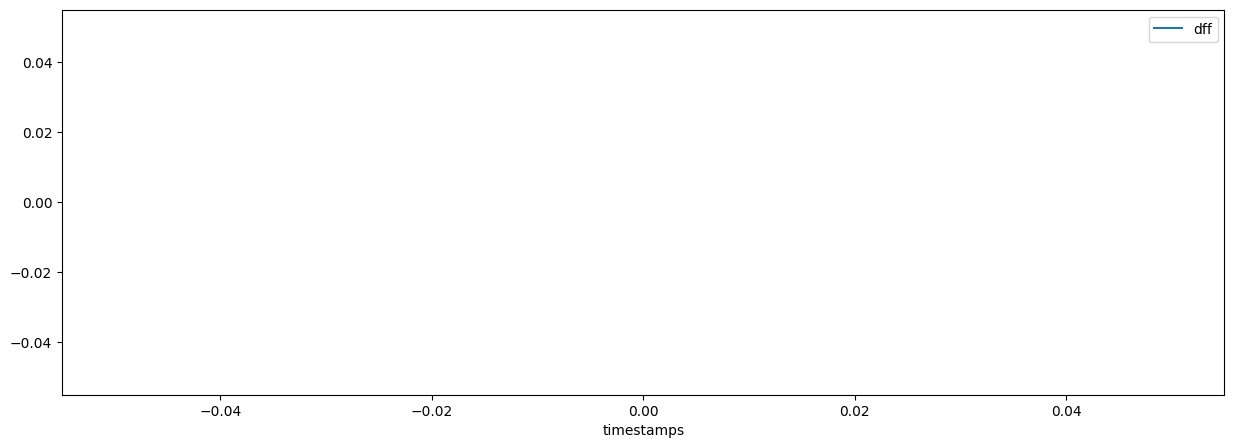

In [83]:
fig, ax = plt.subplots(figsize=(15,5))
single_cell_timeseries.plot(
    x = 'timestamps',
    y = 'dff',
    ax = ax
)
fig.show()

In [84]:
stimulus_table = experiments[ophys_experiment_ids[0]].stimulus_presentations
stimulus_table.head(10)

,stimulus_block,stimulus_block_name,image_index,image_name,movie_frame_index,duration,start_time,end_time,start_frame,end_frame,is_change,is_image_novel,omitted,movie_repeat,flashes_since_change,trials_id,is_sham_change,stimulus_name,active
stimulus_presentations_id,,,,,,,,,,,,,,,,,,,
0,0,initial_gray_screen_5min,-99,NaN,-99,308.624118,0.000000,308.624118,0,17986,False,<NA>,<NA>,-99,0,-99,False,spontaneous,False
1,1,change_detection_passive,0,im036_r,-99,0.250220,308.624118,308.874338,17986,18001,False,False,False,-99,1,0,False,Natural_Images_Lum_Matched_set_ophys_G_2019,True
2,1,change_detection_passive,0,im036_r,-99,0.250190,309.374738,309.624928,18031,18046,False,False,False,-99,2,0,False,Natural_Images_Lum_Matched_set_ophys_G_2019,True
3,1,change_detection_passive,0,im036_r,-99,0.250220,310.125328,310.375548,18076,18091,False,False,False,-99,3,0,False,Natural_Images_Lum_Matched_set_ophys_G_2019,True
4,1,change_detection_passive,0,im036_r,-99,0.250210,310.875938,311.126148,18121,18136,False,False,False,-99,4,0,False,Natural_Images_Lum_Matched_set_ophys_G_2019,True
5,1,change_detection_passive,0,im036_r,-99,0.250200,311.626568,311.876768,18166,18181,False,False,False,-99,5,0,False,Natural_Images_Lum_Matched_set_ophys_G_2019,True
6,1,change_detection_passive,0,im036_r,-99,0.250210,312.377198,312.627408,18211,18226,False,False,False,-99,6,0,True,Natural_Images_Lum_Matched_set_ophys_G_2019,True
7,1,change_detection_passive,0,im036_r,-99,0.250150,313.127848,313.377998,18256,18271,False,False,False,-99,7,0,False,Natural_Images_Lum_Matched_set_ophys_G_2019,True
8,1,change_detection_passive,0,im036_r,-99,0.250230,313.878398,314.128628,18301,18316,False,False,False,-99,8,0,False,Natural_Images_Lum_Matched_set_ophys_G_2019,True


In [85]:
experiment = experiments[ophys_experiment_ids[0]]
experiment.stimulus_templates

,unwarped,warped
image_name,,
im036_r,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[70, 71, 67, 63, 64, 69, 73, 73, 71, 70, 73, ..."
im012_r,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[25, 27, 21, 14, 15, 23, 29, 28, 22, 18, 20, ..."
im044_r,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[20, 23, 16, 9, 9, 18, 24, 23, 16, 12, 14, 20..."
im047_r,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[63, 65, 62, 58, 58, 63, 67, 67, 65, 64, 65, ..."
im083_r,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[6, 9, 2, 0, 0, 0, 7, 5, 0, 0, 0, 2, 7, 6, 2,..."
im111_r,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[53, 55, 50, 44, 45, 51, 56, 56, 52, 49, 50, ..."
im115_r,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[109, 109, 109, 108, 108, 110, 111, 111, 110,..."
im078_r,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[38, 38, 31, 24, 25, 33, 39, 37, 32, 30, 33, ..."


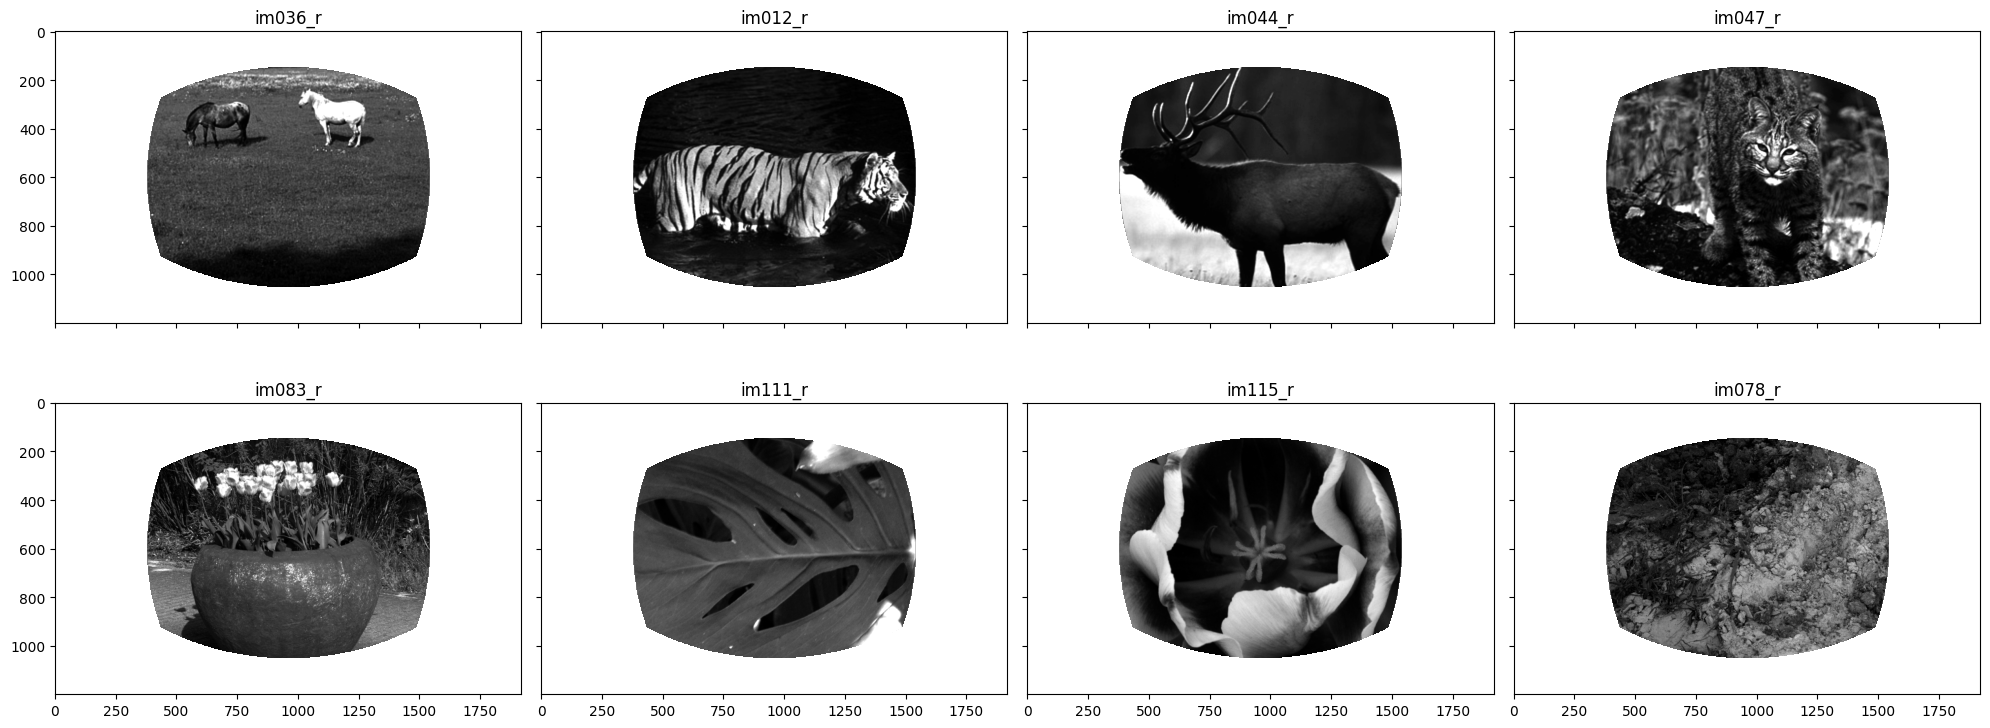

In [86]:
fig, ax = plt.subplots(2, 4, figsize=(20, 8), sharex=True, sharey=True)
for ii, image_name in enumerate(experiment.stimulus_templates.index):
    ax.flatten()[ii].imshow(experiment.stimulus_templates.loc[image_name]['unwarped'], cmap='gray')
    ax.flatten()[ii].set_title(image_name)
fig.tight_layout()
fig.show()


In [90]:
#np.unique(session_table['image_set'])
#session_table[session_table['image_set'] == 'images_G']

#np.unique(stimulus_table['omitted'])

stimulus_table
# = stimulus_table.dropna()
#timulus_table['omitted'].unique()

#stimulus_table.query('image_index').head(10)


,stimulus_block,stimulus_block_name,image_index,image_name,movie_frame_index,duration,start_time,end_time,start_frame,end_frame,is_change,is_image_novel,omitted,movie_repeat,flashes_since_change,trials_id,is_sham_change,stimulus_name,active
stimulus_presentations_id,,,,,,,,,,,,,,,,,,,
1,1,change_detection_passive,0,im036_r,-99,0.25022,308.624118,308.874338,17986,18001,False,False,False,-99,1,0,False,Natural_Images_Lum_Matched_set_ophys_G_2019,True
2,1,change_detection_passive,0,im036_r,-99,0.25019,309.374738,309.624928,18031,18046,False,False,False,-99,2,0,False,Natural_Images_Lum_Matched_set_ophys_G_2019,True
3,1,change_detection_passive,0,im036_r,-99,0.25022,310.125328,310.375548,18076,18091,False,False,False,-99,3,0,False,Natural_Images_Lum_Matched_set_ophys_G_2019,True
4,1,change_detection_passive,0,im036_r,-99,0.25021,310.875938,311.126148,18121,18136,False,False,False,-99,4,0,False,Natural_Images_Lum_Matched_set_ophys_G_2019,True
5,1,change_detection_passive,0,im036_r,-99,0.25020,311.626568,311.876768,18166,18181,False,False,False,-99,5,0,False,Natural_Images_Lum_Matched_set_ophys_G_2019,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4797,1,change_detection_passive,5,im111_r,-99,0.25020,3909.248618,3909.498818,233847,233862,True,False,False,-99,0,409,False,Natural_Images_Lum_Matched_set_ophys_G_2019,True
4799,1,change_detection_passive,5,im111_r,-99,0.25022,3910.749848,3911.000068,233937,233952,False,False,False,-99,1,409,False,Natural_Images_Lum_Matched_set_ophys_G_2019,True
4800,1,change_detection_passive,5,im111_r,-99,0.25022,3911.500438,3911.750658,233982,233997,False,False,False,-99,2,409,False,Natural_Images_Lum_Matched_set_ophys_G_2019,True
